In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = {
    'Customer_ID':[101,102,103,104,105,106,107,108,109,110,111,112,113,114,115],
    'Review':['Excellent product','Good quality','Average performance',
              'Very bad experience','Worth the price','Not satisfied',
              'Great features','Poor packaging','Excellent service',
              'Good product','Bad quality','Nice design',
              'Average','Good value','Excellent'],
    'Rating':[5,4,np.nan,1,6,2,5,0,5,4,1,4,3,4,50],
    'Product_Category':['Electronics','Electronics','Electronics',
                        'Home','Electronics','Home',
                        np.nan,'Home','Electronics',
                        'Electronics','Home','Electronics',
                        'Home','Electronics','Electronics']
}

In [3]:
df = pd.DataFrame(data)

print("Original Dataset:")
print(df)
print(df.head())
print(df.tail())
print(df.info())

Original Dataset:
    Customer_ID               Review  Rating Product_Category
0           101    Excellent product     5.0      Electronics
1           102         Good quality     4.0      Electronics
2           103  Average performance     NaN      Electronics
3           104  Very bad experience     1.0             Home
4           105      Worth the price     6.0      Electronics
5           106        Not satisfied     2.0             Home
6           107       Great features     5.0              NaN
7           108       Poor packaging     0.0             Home
8           109    Excellent service     5.0      Electronics
9           110         Good product     4.0      Electronics
10          111          Bad quality     1.0             Home
11          112          Nice design     4.0      Electronics
12          113              Average     3.0             Home
13          114           Good value     4.0      Electronics
14          115            Excellent    50.0      El

Missing values filling

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing rating with median
df['Rating'].fillna(df['Rating'].median(), inplace=True)

# Fill missing category with mode
df['Product_Category'].fillna(
    df['Product_Category'].mode()[0],
    inplace=True
)


Missing Values:
Customer_ID         0
Review              0
Rating              1
Product_Category    1
dtype: int64


C:\Users\SHARAYU SHELKE\AppData\Local\Temp\ipykernel_17140\4117696239.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Rating'].fillna(df['Rating'].median(), inplace=True)
C:\Users\SHARAYU SHELKE\AppData\Local\Temp\ipykernel_17140\4117696239.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series 

0     Electronics
1     Electronics
2     Electronics
3            Home
4     Electronics
5            Home
6     Electronics
7            Home
8     Electronics
9     Electronics
10           Home
11    Electronics
12           Home
13    Electronics
14    Electronics
Name: Product_Category, dtype: str

In [11]:
df.loc[df['Rating'] < 1, 'Rating'] = np.nan
df.loc[df['Rating'] > 5, 'Rating'] = np.nan

# Replace invalid ratings with median
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
print("\nDataset after cleaning:")
print(df)


Dataset after cleaning:
    Customer_ID               Review  Rating Product_Category  \
0           101    Excellent product     5.0      Electronics   
1           102         Good quality     4.0      Electronics   
2           103  Average performance     4.0      Electronics   
3           104  Very bad experience     1.0             Home   
4           105      Worth the price     4.0      Electronics   
5           106        Not satisfied     2.0             Home   
6           107       Great features     5.0              NaN   
7           108       Poor packaging     4.0             Home   
8           109    Excellent service     5.0      Electronics   
9           110         Good product     4.0      Electronics   
10          111          Bad quality     1.0             Home   
11          112          Nice design     4.0      Electronics   
12          113              Average     3.0             Home   
13          114           Good value     4.0      Electronics   


Outliers detection using IQR

In [12]:
Q1 = df['Rating'].quantile(0.25)
Q3 = df['Rating'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nLower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df['Rating'] < lower_bound) |
              (df['Rating'] > upper_bound)]

print("\nOutliers:")
print(outliers)


Lower Bound: 2.75
Upper Bound: 4.75

Outliers:
    Customer_ID               Review  Rating Product_Category  \
0           101    Excellent product     5.0      Electronics   
3           104  Very bad experience     1.0             Home   
5           106        Not satisfied     2.0             Home   
6           107       Great features     5.0              NaN   
8           109    Excellent service     5.0      Electronics   
10          111          Bad quality     1.0             Home   

    Rating_Normalized  
0            0.547945  
3            0.109589  
5            0.219178  
6            0.547945  
8            0.547945  
10           0.109589  


In [13]:
# Cap outliers
df['Rating'] = np.where(
    df['Rating'] > upper_bound,
    upper_bound,
    df['Rating']
)

df['Rating'] = np.where(
    df['Rating'] < lower_bound,
    lower_bound,
    df['Rating']
)


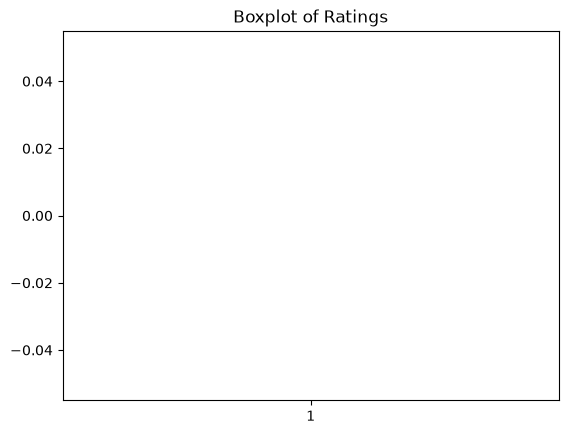

In [7]:
# Boxplot
plt.boxplot(df['Rating'])
plt.title("Boxplot of Ratings")
plt.show()

Data Transformation


Dataset after Transformation:
    Customer_ID               Review  Rating Product_Category  \
0           101    Excellent product    4.75      Electronics   
1           102         Good quality    4.00      Electronics   
2           103  Average performance    4.00      Electronics   
3           104  Very bad experience    2.75             Home   
4           105      Worth the price    4.00      Electronics   
5           106        Not satisfied    2.75             Home   
6           107       Great features    4.75              NaN   
7           108       Poor packaging    4.00             Home   
8           109    Excellent service    4.75      Electronics   
9           110         Good product    4.00      Electronics   
10          111          Bad quality    2.75             Home   
11          112          Nice design    4.00      Electronics   
12          113              Average    3.00             Home   
13          114           Good value    4.00      Electroni

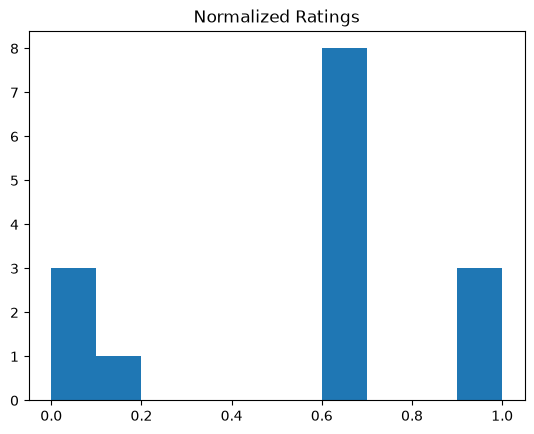

In [14]:

# Min-Max Scaling
df['Rating_Normalized'] = (
    (df['Rating'] - df['Rating'].min()) /
    (df['Rating'].max() - df['Rating'].min())
)

print("\nDataset after Transformation:")
print(df)

# Histogram
plt.hist(df['Rating_Normalized'])
plt.title("Normalized Ratings")
plt.show()